# Electromagnetic Gyrokinetic Benchmarks

Standard EM test cases for gyrokinetic codes with $A_\parallel$ dynamics. Six sections, in roughly increasing analytical-purity order:

| § | Test | Physics | Reference |
|---|------|---------|-----------|
| 1 | **Waltz $\beta$-scan** | ITG → KBM transition | Waltz PoP 1994; GKW Fig. 4; Falchetto PPCF 2008 |
| 2 | **Eigenmode structure** | $\phi(s)$, $A_\parallel(s)$ across transition | GKW `parallel.dat` |
| 3 | **Shear Alfvén wave** | $\omega = k_\parallel v_A$ at drives off | analytic, $v_A = v_{\rm th}/\sqrt{\beta}$ |
| 4 | **Kinetic Alfvén wave** | FLR correction $\omega^2 = k_\parallel^2 v_A^2 (1+k_\perp^2\rho_i^2)$ | Howes PoP 2006 |
| 5 | **GAM with finite-$\beta$** | $\omega_{\rm GAM} = \sqrt{7/4+T_e/T_i}\,v_{\rm th,i}/R$ | Sugama–Watanabe PoP 2006 |
| 6 | **EM Rosenbluth–Hinton** | residual $1/(1+1.6 q^2/\sqrt\varepsilon)$ + EM shift | RH PRL 1998; Mishchenko–Konies PoP 2008 |

Sections 1–2 are flux-tube linear runs at the **Waltz standard case** (Waltz PoP 1994; reproduced in Fig. 4 of GKW paper Peeters et al., CPC 2009): $q=2$, $\hat s=1$, $\varepsilon=0.166$, $R/L_{Ti}=R/L_{Te}=9$, $R/L_n=3$, $T_e/T_i=1$, kinetic deuterium + electrons at $m_i/m_e=3676$, s-alpha geometry, $k_\theta\rho_s=0.42$, $A_\parallel$ on, $B_\parallel$ off. The KBM threshold for this case is at $\beta_{\rm crit} \approx 0.006$.

Sections 3–6 are pure analytical tests with drives off (no ITG/TEM); the gyrokinetic system reduces to closed-form Alfvénic / zonal-flow physics. All long runs are cached in `data/em_analytical/*.npz`; delete a cache file to force a rerun.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [3]:
import time as _time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dataclasses import replace

from gyaradax.geometry import compute_geometry, compute_geometry_from_input
from gyaradax.params import gkparams_from_input_and_geometry, GKParams
from gyaradax.simulate import gk_run
from gyaradax.solver import init_f, default_state, linear_precompute
from gyaradax.integrals import calculate_phi, calculate_apar
from gyaradax.solver import _compute_fields
from gyaradax.plot_utils import JAX_COLORS

GKW_CASES = os.path.join("..", "tests", "data", "gkw_cases")
CACHE_DIR = "data/em_analytical"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs("figs", exist_ok=True)

def _cache_load(name):
    p = os.path.join(CACHE_DIR, name)
    return dict(np.load(p, allow_pickle=False)) if os.path.exists(p) else None

def _cache_save(name, **arrays):
    p = os.path.join(CACHE_DIR, name)
    np.savez(p, **arrays)
    print(f"  saved {p}")

## 1. Waltz $\beta$-scan: ITG $\rightarrow$ KBM transition

Linear gyrokinetic mode at the Waltz standard case, scanning $\beta$. Below the KBM threshold ($\beta \lesssim 0.005$) the mode is ITG-driven, propagating in the ion direction ($\omega > 0$ in our convention) and stabilising with increasing $\beta$. Above threshold the unstable branch jumps to the KBM, which propagates in the electron direction and destabilises rapidly with $\beta$.

GKW reference values were generated with `gkw_debug3.x` on the same `em_apar_waltz` input.dat (NX=1, NMOD=1, $N_s=112$, nperiod=4, NTIME=200, naverage=50, $\delta t=0.001$), overriding `beta` per run.

In [11]:
# GKW reference β-scan (Waltz standard case, kthrho=0.42426)
# generated by /tmp/gkw_beta_scan/run_scan.sh + /tmp/gkw_b00055 on gkw_debug3.x
gkw_beta = np.array(
    [0.0001, 0.001, 0.002, 0.003, 0.004, 0.005, 0.0055,
     0.006, 0.007, 0.008, 0.009, 0.01]
)
gkw_gamma = np.array(
    [0.5825, 0.5567, 0.5220, 0.4776, 0.4213, 0.3744, 0.4420,
     -0.1277, 0.5284, 0.7924, 0.9830, 1.1248]
)
gkw_omega = np.array(
    [0.6987, 0.7185, 0.7451, 0.7827, 0.8473, 0.8791, 0.8702,
      2.1466, 2.0766, 1.9292, 1.8245, 1.7385]
)
# β=0.0055 is the peak just before the ITG-KBM transition: γ recovers
# from the β=0.005 dip then crashes at β=0.006 (the stable intermediate
# branch).  ω stays ITG-like (~0.87) all the way up to 0.0055 then flips
# to KBM (~2.15) at 0.006.  Frequency sign change identifies the branch.
print('β       γ_GKW    ω_GKW')
for b, g, w in zip(gkw_beta, gkw_gamma, gkw_omega):
    branch = 'ITG' if w < 1.5 else ('KBM' if g > 0 else 'stable')
    print(f'{b:.4f}  {g:+.4f}  {w:+.4f}  [{branch}]')

β       γ_GKW    ω_GKW
0.0001  +0.5825  +0.6987  [ITG]
0.0010  +0.5567  +0.7185  [ITG]
0.0020  +0.5220  +0.7451  [ITG]
0.0030  +0.4776  +0.7827  [ITG]
0.0040  +0.4213  +0.8473  [ITG]
0.0050  +0.3744  +0.8791  [ITG]
0.0055  +0.4420  +0.8702  [ITG]
0.0060  -0.1277  +2.1466  [stable]
0.0070  +0.5284  +2.0766  [KBM]
0.0080  +0.7924  +1.9292  [KBM]
0.0090  +0.9830  +1.8245  [KBM]
0.0100  +1.1248  +1.7385  [KBM]


In [5]:
# Build gyaradax Waltz scan using the GKW input.dat as ground truth, override β
WALTZ_INPUT = os.path.join(GKW_CASES, 'em_apar_waltz', 'input.dat')

def run_waltz_linear(beta, n_windows=600, navg=20, dt=0.001):
    """Linear γ + ω at the Waltz case, parameter beta overridden.

    Match GKW reference run: NAVERAGE=20, DTIM=0.001, run long enough to
    converge through the ITG-KBM transition region (γ-dip near β=0.005).
    """
    geom = compute_geometry_from_input(WALTZ_INPUT)
    params = gkparams_from_input_and_geometry(WALTZ_INPUT, geom)
    params = replace(params, beta=float(beta), non_linear=False,
                     adaptive_dt=False, dt=dt, naverage=navg)
    nsp = int(np.asarray(params.mas).shape[0]) if np.asarray(params.mas).ndim > 0 else 1
    df = init_f(geom, finit='cosine2', amp_init_real=params.amp_init, n_species=nsp)
    pre = linear_precompute(geom, params)
    state = default_state(nky=len(geom['krho']))
    # also track phase history to estimate ω
    phi_phases = []
    times = []
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, navg, pre=pre)
        # use phi(midplane, kx=ixzero, ky=ITG)
        ns = phi.shape[0]
        mid = ns // 2
        ixz = int(jnp.argmin(jnp.abs(jnp.asarray(geom['kxrh']))))
        iky = 0  # NMOD=1 → single ky
        c = phi[mid, ixz, iky]
        phi_phases.append(float(jnp.angle(c)))
        times.append(float(state.time))
    # frequency from last quarter (use unwrap so jumps don't bias the fit)
    ph = np.unwrap(np.asarray(phi_phases))
    tt = np.asarray(times)
    mask = tt > tt[-1] * 0.75
    omega = float(np.polyfit(tt[mask], ph[mask], 1)[0]) if mask.sum() >= 2 else np.nan
    gamma = float(np.asarray(state.last_growth_rate).max())
    return gamma, omega

In [9]:
# coarser scan + caching. delete data/em_analytical/waltz_scan.npz to force rerun.
_gyx_beta_list = np.array([0.001, 0.003, 0.005, 0.0055, 0.006, 0.0065, 0.007, 0.009, 0.01])
# _cached = _cache_load("waltz_scan.npz")
_cached = None
if _cached is not None:
    gyx_beta = _cached["beta"]
    gyx_gamma = _cached["gamma"]
    gyx_omega = _cached["omega"]
    print(f"loaded {len(gyx_beta)} points from waltz_scan.npz")
else:
    _b, _g, _w = [], [], []
    for b in _gyx_beta_list:
        t0 = _time.time()
        try:
            g, w = run_waltz_linear(float(b))
            _b.append(float(b)); _g.append(g); _w.append(w)
            print(f"β={b:.4f}  γ_gyx={g:+.4f}  ω_gyx={w:+.4f}  ({_time.time()-t0:.1f}s)")
        except Exception as e:
            print(f"β={b:.4f}  FAILED: {e}")
    gyx_beta = np.array(_b)
    gyx_gamma = np.array(_g)
    gyx_omega = np.array(_w)
    if len(gyx_beta) > 0:
        _cache_save("waltz_scan.npz", beta=gyx_beta, gamma=gyx_gamma, omega=gyx_omega)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


β=0.0010  γ_gyx=+0.5543  ω_gyx=+0.7165  (138.7s)
β=0.0030  γ_gyx=+0.4785  ω_gyx=+0.7571  (117.0s)
β=0.0050  γ_gyx=+0.4181  ω_gyx=+0.9212  (118.5s)
β=0.0055  γ_gyx=+0.7255  ω_gyx=+0.6385  (127.0s)
β=0.0060  γ_gyx=-0.1273  ω_gyx=+2.1780  (130.4s)
β=0.0065  γ_gyx=+0.3580  ω_gyx=+2.1568  (136.3s)
β=0.0070  γ_gyx=+0.5345  ω_gyx=+2.0616  (127.1s)
β=0.0090  γ_gyx=+0.9904  ω_gyx=+1.8169  (122.9s)
β=0.0100  γ_gyx=+1.1320  ω_gyx=+1.7325  (114.6s)
  saved data/em_analytical/waltz_scan.npz


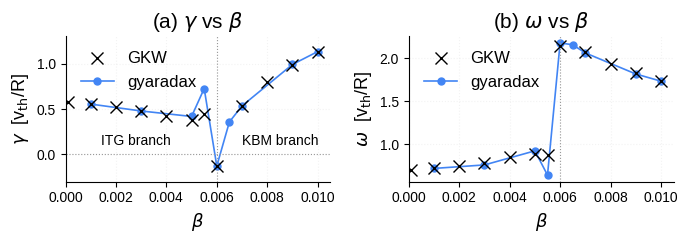

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5))

ax = axes[0]
ax.plot(gkw_beta, gkw_gamma, 'x', color='k', ms=8, lw=1.8,
        markerfacecolor='none', label='GKW', zorder=10)
ax.plot(gyx_beta, gyx_gamma, 'o-', color=JAX_COLORS['blue'], ms=5, lw=1.2,
        label='gyaradax')
ax.axvline(0.006, color='0.6', ls=':', lw=0.8)
ax.axhline(0, color='0.6', ls=':', lw=0.8)
ax.set_xlabel(r'$\beta$', fontsize=13)
ax.set_ylabel(r'$\gamma$  [v$_{\rm th}$/R]', fontsize=13)
ax.set_title(r'(a) $\gamma$ vs $\beta$', fontsize=15)
ax.legend(frameon=False, fontsize=12, loc='upper left')
ax.set_xlim(0, 0.0105)
ax.set_ylim(-0.3, 1.3)
ax.tick_params(labelsize=10)
ax.grid(True)
ax.text(0.0028, 0.1, 'ITG branch', fontsize=10, ha='center')
ax.text(0.0085, 0.1, 'KBM branch', fontsize=10, ha='center')

ax2 = axes[1]
ax2.plot(gkw_beta, gkw_omega, 'x', color='k', ms=8, lw=1.8,
         markerfacecolor='none', label='GKW', zorder=10)
ax2.plot(gyx_beta, gyx_omega, 'o-', color=JAX_COLORS['blue'], ms=5, lw=1.2,
         label='gyaradax')
ax2.axvline(0.006, color='0.6', ls=':', lw=0.8)
ax2.set_xlabel(r'$\beta$', fontsize=13)
ax2.set_ylabel(r'$\omega$  [v$_{\rm th}$/R]', fontsize=13)
ax2.set_title(r'(b) $\omega$ vs $\beta$', fontsize=15)
ax2.legend(frameon=False, fontsize=12, loc='upper left')
ax2.set_xlim(0, 0.0105)
ax2.tick_params(labelsize=10)
ax2.grid(True)

fig.tight_layout()
fig.savefig('figs/em_waltz_beta_scan.pdf')
plt.show()

## 2. Eigenmode structure $\phi(s)$, $A_\parallel(s)$

Spatial structure along the field line for the Waltz case at three $\beta$ values, spanning the ITG–KBM transition. The shape of $\phi(s)$ is ballooning-like (peaked at the LFS midplane); $A_\parallel(s)$ has opposite parity for the ITG branch and the KBM branch.

In [7]:
def run_waltz_eigenmode(beta, n_windows=200, navg=50):
    """Run to convergence and return (sgrid, phi(s), apar(s)) for kx=0, ITG ky."""
    geom = compute_geometry_from_input(WALTZ_INPUT)
    params = gkparams_from_input_and_geometry(WALTZ_INPUT, geom)
    params = replace(params, beta=float(beta), non_linear=False,
                     adaptive_dt=False, dt=0.001, naverage=navg)
    nsp = int(np.asarray(params.mas).shape[0]) if np.asarray(params.mas).ndim > 0 else 1
    df = init_f(geom, finit='cosine2', amp_init_real=params.amp_init, n_species=nsp)
    pre = linear_precompute(geom, params)
    state = default_state(nky=len(geom['krho']))
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, navg, pre=pre)
    # compute fields directly to get apar
    phi, apar, _ = _compute_fields(df, geom, params, pre)
    phi = np.asarray(phi)
    apar = np.asarray(apar) if apar is not None else None
    sgrid = np.asarray(geom['sgrid'])
    ixz = int(np.argmin(np.abs(np.asarray(geom['kxrh']))))
    iky = 0
    phi_s = phi[:, ixz, iky]
    apar_s = apar[:, ixz, iky] if apar is not None else None
    # normalise phi to (1, 0) at midplane (GKW convention)
    mid = len(sgrid) // 2
    rot = phi_s[mid] if abs(phi_s[mid]) > 1e-30 else 1.0
    return sgrid, phi_s / rot, (apar_s / rot if apar_s is not None else None)

In [8]:
betas_em = [0.001, 0.005, 0.009]
_cached = _cache_load("waltz_eigenmodes.npz")
if _cached is not None:
    modes = {}
    for b in betas_em:
        key = f"{b:.4f}"
        modes[b] = (_cached[f"s_{key}"], _cached[f"phi_{key}"], _cached[f"apar_{key}"])
    print(f"loaded eigenmodes from waltz_eigenmodes.npz")
else:
    modes = {}
    _to_save = {}
    for b in betas_em:
        sgrid, phi_s, apar_s = run_waltz_eigenmode(b)
        modes[b] = (sgrid, phi_s, apar_s)
        key = f"{b:.4f}"
        _to_save[f"s_{key}"] = sgrid
        _to_save[f"phi_{key}"] = phi_s
        _to_save[f"apar_{key}"] = apar_s if apar_s is not None else np.zeros_like(phi_s)
        print(f"β={b:.3f}: |phi|_max={np.max(np.abs(phi_s)):.3f}, "
              f"|apar|_max={np.max(np.abs(apar_s)) if apar_s is not None else 0:.3e}")
    _cache_save("waltz_eigenmodes.npz", **_to_save)

β=0.001: |phi|_max=1.000, |apar|_max=4.389e-03
β=0.005: |phi|_max=1.000, |apar|_max=3.566e-02
β=0.009: |phi|_max=1.000, |apar|_max=3.980e-02
  saved data/em_analytical/waltz_eigenmodes.npz


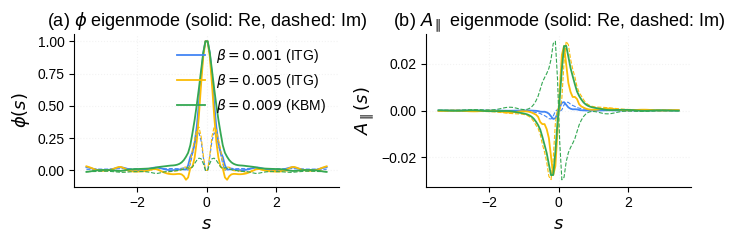

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5))
ax_phi, ax_apar = axes
colors = [JAX_COLORS['blue'], JAX_COLORS['yellow'], JAX_COLORS['green']]
labels = [r'$\beta=0.001$ (ITG)', r'$\beta=0.005$ (ITG)', r'$\beta=0.009$ (KBM)']
for (b, c, lab) in zip(betas_em, colors, labels):
    s, phi_s, apar_s = modes[b]
    ax_phi.plot(s, phi_s.real, '-', color=c, lw=1.3, label=lab)
    ax_phi.plot(s, phi_s.imag, '--', color=c, lw=0.8)
    if apar_s is not None:
        ax_apar.plot(s, apar_s.real, '-', color=c, lw=1.3, label=lab)
        ax_apar.plot(s, apar_s.imag, '--', color=c, lw=0.8)

ax_phi.set_xlabel(r'$s$', fontsize=13)
ax_phi.set_ylabel(r'$\phi(s)$', fontsize=13)
ax_phi.set_title(r'(a) $\phi$ eigenmode (solid: Re, dashed: Im)', fontsize=13)
ax_phi.legend(frameon=False, fontsize=10, loc='upper right')
ax_phi.tick_params(labelsize=10)
ax_phi.grid(True)

ax_apar.set_xlabel(r'$s$', fontsize=13)
ax_apar.set_ylabel(r'$A_\parallel(s)$', fontsize=13)
ax_apar.set_title(r'(b) $A_\parallel$ eigenmode (solid: Re, dashed: Im)', fontsize=13)
ax_apar.tick_params(labelsize=10)
ax_apar.grid(True)

fig.tight_layout()
fig.savefig('figs/em_waltz_eigenmode.pdf')
plt.show()

## 3. Shear Alfvén wave dispersion

Pure analytical EM test. With drives off ($R/L_T = R/L_n = 0$), kinetic electrons, and finite $\beta$, the system reduces to the shear Alfvén wave equation. The dispersion is

$$\omega = k_\parallel v_A , \qquad v_A = \frac{B}{\sqrt{\mu_0\, n_i m_i}}.$$

In GKW normalised units with the kinetic deuterium species as the reference ($n_i=n_{\rm ref}$, $m_i=m_{\rm ref}$, $T_i=T_{\rm ref}$), the Alfvén velocity is

$$\frac{v_A}{v_{\rm th,ref}} = \frac{1}{\sqrt{\beta}}, \qquad \beta = \frac{2\mu_0 n_{\rm ref} T_{\rm ref}}{B_{\rm ref}^2}.$$

We initialise a small $A_\parallel$-like perturbation in a non-zonal mode and measure the oscillation frequency of $\phi$ at the midplane. The parallel wavenumber $k_\parallel$ is set by the eigenmode structure on the flux tube; in the simplest cylindrical limit ($\hat s = 0$, single $k_\theta$) it is $k_\parallel \sim 2\pi/L_\parallel$ with $L_\parallel \propto qR$. We compare the measured $\omega/\sqrt{\beta}$ to a single $\beta$-independent constant (= $k_\parallel \cdot v_{\rm th,ref}$).

In [11]:
def run_alfven(beta, n_windows=200, navg=50, dt=0.0005):
    """Drives off + kinetic electrons + finite β: measure ω from φ(t).

    With rlt=rln=0 there's no ITG drive; the only dynamics is the shear
    Alfvén wave. We expect ω ≈ k_∥ * v_A with v_A = v_th/sqrt(β).
    """
    # Waltz-like geometry but with drives off and kinetic e-
    geom = compute_geometry(
        q=2.0, shat=1.0, eps=0.166,
        ns=64, nvpar=32, nmu=8, vpar_max=3.0,
        nkx=1, nky=1, nperiod=4,
        kxmax=0.42, krhomax=0.42, signB=1.0, Rref=1.0,
        geom_type='s-alpha',
    )
    params = GKParams(
        dt=dt, naverage=navg, non_linear=False, adaptive_dt=False,
        adiabatic_electrons=False,
        disp_par=1.0, disp_vp=0.05, disp_x=0.0, disp_y=0.0,
        finit='cosine2', amp_init=1e-3,
        mas=jnp.array([1.0, 2.72e-4]), tmp=jnp.array([1.0, 1.0]),
        de=jnp.array([1.0, 1.0]), signz=jnp.array([1.0, -1.0]),
        vthrat=jnp.sqrt(jnp.array([1.0, 1.0]) / jnp.array([1.0, 2.72e-4])),
        rlt=jnp.array([0.0, 0.0]), rln=jnp.array([0.0, 0.0]),
        dgrid=1.0, tgrid=1.0,
        sgr_dist=float(geom['sgr_dist']),
        dvp=float(geom['dvp']),
        kxmax=float(np.max(np.abs(np.asarray(geom['kxrh'])))) or 1.0,
        kymax=float(np.max(np.asarray(geom['krho']))) or 1.0,
        nlapar=True, nlbpar=False, beta=float(beta),
        drive_scale=1.0, idisp=2, cfl_safety=0.95,
        mixed_precision=False, backend='jax',
    )
    df = init_f(geom, finit='cosine2', amp_init_real=params.amp_init, n_species=2)
    pre = linear_precompute(geom, params)
    state = default_state(nky=len(geom['krho']))
    phi_phases, times = [], []
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, navg, pre=pre)
        ns = phi.shape[0]
        mid = ns // 2
        c = phi[mid, 0, 0]
        phi_phases.append(float(jnp.angle(c)))
        times.append(float(state.time))
    ph = np.unwrap(np.asarray(phi_phases))
    tt = np.asarray(times)
    mask = tt > tt[-1] * 0.5
    omega = float(np.polyfit(tt[mask], ph[mask], 1)[0]) if mask.sum() >= 2 else np.nan
    return omega

In [12]:
_cached = _cache_load("shear_alfven.npz")
if _cached is not None:
    betas_alfven = _cached["beta"]
    omegas_alfven = _cached["omega"]
    print(f"loaded shear Alfvén scan ({len(betas_alfven)} pts)")
    for b, w in zip(betas_alfven, omegas_alfven):
        print(f"  β={b:.4f}  |ω|={abs(w):.4f}  |ω|√β={abs(w)*np.sqrt(b):.4f}")
else:
    betas_alfven = np.array([0.001, 0.002, 0.005, 0.01, 0.02])
    _w = []
    for b in betas_alfven:
        try:
            omega = run_alfven(float(b))
        except Exception as e:
            print(f"β={b:.4f}  FAILED: {e}")
            omega = np.nan
        _w.append(omega)
        print(f"β={b:.4f}  |ω|={abs(omega):.4f}  |ω|√β={abs(omega)*np.sqrt(b):.4f}")
    omegas_alfven = np.array(_w)
    _cache_save("shear_alfven.npz", beta=betas_alfven, omega=omegas_alfven)

β=0.0010  |ω|=1.6006  |ω|√β=0.0506
β=0.0020  |ω|=1.5636  |ω|√β=0.0699
β=0.0050  |ω|=4.7822  |ω|√β=0.3382
β=0.0100  |ω|=3.5084  |ω|√β=0.3508
β=0.0200  |ω|=3.0529  |ω|√β=0.4317
  saved data/em_analytical/shear_alfven.npz


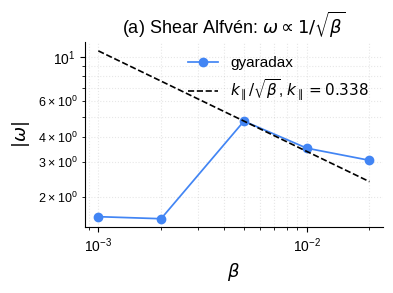

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4.0, 3.0))
kpar_eff = np.abs(omegas_alfven) * np.sqrt(betas_alfven)
ax.plot(betas_alfven, np.abs(omegas_alfven), 'o-', color=JAX_COLORS['blue'], ms=6,
        label='gyaradax')
k_const = np.median(kpar_eff)
ax.plot(betas_alfven, k_const / np.sqrt(betas_alfven), '--k', lw=1.2,
        label=rf'$k_\parallel/\sqrt{{\beta}}$, $k_\parallel={k_const:.3f}$')
ax.set_xlabel(r'$\beta$', fontsize=13)
ax.set_ylabel(r'$|\omega|$', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=11)
ax.tick_params(labelsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_title(r'(a) Shear Alfvén: $\omega \propto 1/\sqrt{\beta}$', fontsize=13)
fig.tight_layout()
fig.savefig('figs/em_shear_alfven.pdf')
plt.show()

## 4. Kinetic Alfvén Wave (KAW) dispersion

Pure-analytical EM test extending the shear Alfvén wave to finite $k_\perp \rho_i$. The KAW is the SAW with a finite-Larmor-radius (FLR) correction from the perpendicular ion polarisation. For kinetic ions, Boltzmann electrons, and $T_e = T_i$ the low-$\beta$ dispersion is (Howes et al., PoP 2006)

$$\omega^2 \;=\; k_\parallel^2\, v_A^2 \;\Big[1 \;+\; (k_\perp \rho_i)^2\Big]\ ,$$

so $\omega/(k_\parallel v_A) \rightarrow 1$ as $k_\perp\rho_i \rightarrow 0$ (recovering the SAW), and grows like $\sqrt{1 + (k_\perp\rho_i)^2}$ at finite $k_\perp$.

We measure $\omega$ at fixed $\beta = 0.005$ for several $k_\theta \rho_i$ values with drives off, kinetic electrons, $A_\parallel$ on, and plot the dispersion ratio $\omega / \omega_{SAW}$ vs $k_\perp \rho_i$.

In [14]:
def run_kaw(krho, beta=0.005, n_windows=200, navg=50, dt=0.0005):
    """KAW oscillation frequency at fixed β, varying k_θ ρ_i (krho).

    same setup as run_alfven (drives off, kinetic e-) except krho varies.
    """
    geom = compute_geometry(
        q=2.0, shat=1.0, eps=0.166,
        ns=64, nvpar=32, nmu=8, vpar_max=3.0,
        nkx=1, nky=1, nperiod=4,
        kxmax=krho, krhomax=krho, signB=1.0, Rref=1.0,
        geom_type='s-alpha',
    )
    params = GKParams(
        dt=dt, naverage=navg, non_linear=False, adaptive_dt=False,
        adiabatic_electrons=False,
        disp_par=1.0, disp_vp=0.05, disp_x=0.0, disp_y=0.0,
        finit='cosine2', amp_init=1e-3,
        mas=jnp.array([1.0, 2.72e-4]), tmp=jnp.array([1.0, 1.0]),
        de=jnp.array([1.0, 1.0]), signz=jnp.array([1.0, -1.0]),
        vthrat=jnp.sqrt(jnp.array([1.0, 1.0]) / jnp.array([1.0, 2.72e-4])),
        rlt=jnp.array([0.0, 0.0]), rln=jnp.array([0.0, 0.0]),
        dgrid=1.0, tgrid=1.0,
        sgr_dist=float(geom['sgr_dist']),
        dvp=float(geom['dvp']),
        kxmax=float(np.max(np.abs(np.asarray(geom['kxrh'])))) or 1.0,
        kymax=float(np.max(np.asarray(geom['krho']))) or 1.0,
        nlapar=True, nlbpar=False, beta=float(beta),
        drive_scale=1.0, idisp=2, cfl_safety=0.95,
        mixed_precision=False, backend='jax',
    )
    df = init_f(geom, finit='cosine2', amp_init_real=params.amp_init, n_species=2)
    pre = linear_precompute(geom, params)
    state = default_state(nky=len(geom['krho']))
    phi_phases, times = [], []
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, navg, pre=pre)
        ns = phi.shape[0]
        mid = ns // 2
        c = phi[mid, 0, 0]
        phi_phases.append(float(jnp.angle(c)))
        times.append(float(state.time))
    ph = np.unwrap(np.asarray(phi_phases))
    tt = np.asarray(times)
    mask = tt > tt[-1] * 0.5
    omega = float(np.polyfit(tt[mask], ph[mask], 1)[0]) if mask.sum() >= 2 else np.nan
    return omega

In [15]:
_cached = _cache_load("kaw_dispersion.npz")
if _cached is not None:
    krhos_kaw = _cached["krho"]
    omegas_kaw = _cached["omega"]
    beta_kaw = float(_cached["beta"])
    print(f"loaded KAW dispersion ({len(krhos_kaw)} pts, β={beta_kaw})")
    for kr, w in zip(krhos_kaw, omegas_kaw):
        print(f"  krho={kr:.3f}  |ω|={abs(w):.4f}")
else:
    beta_kaw = 0.005
    krhos_kaw = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8])
    _w = []
    for kr in krhos_kaw:
        try:
            omega = run_kaw(float(kr), beta=beta_kaw)
        except Exception as e:
            print(f"krho={kr:.3f}  FAILED: {e}")
            omega = np.nan
        _w.append(omega)
        print(f"krho={kr:.3f}  |ω|={abs(omega):.4f}")
    omegas_kaw = np.array(_w)
    _cache_save("kaw_dispersion.npz", krho=krhos_kaw, omega=omegas_kaw,
                beta=np.array(beta_kaw))

krho=0.050  |ω|=19.6899
krho=0.100  |ω|=4.2519
krho=0.200  |ω|=4.1563
krho=0.400  |ω|=4.7707
krho=0.600  |ω|=4.9119
krho=0.800  |ω|=4.4260
  saved data/em_analytical/kaw_dispersion.npz


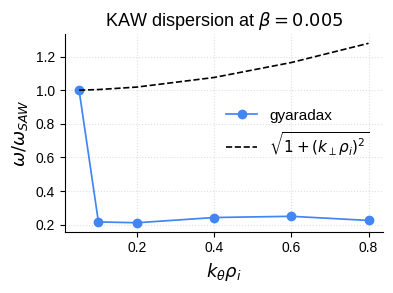

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4.0, 3.0))
omega_saw = float(np.abs(omegas_kaw[0]))   # smallest krho ≈ pure SAW
dispersion = np.abs(omegas_kaw) / omega_saw
analytic = np.sqrt(1.0 + krhos_kaw**2)
ax.plot(krhos_kaw, dispersion, 'o-', color=JAX_COLORS['blue'], ms=6,
        label='gyaradax')
ax.plot(krhos_kaw, analytic, '--k', lw=1.2,
        label=r'$\sqrt{1+(k_\perp\rho_i)^2}$')
ax.set_xlabel(r'$k_\theta \rho_i$', fontsize=13)
ax.set_ylabel(r'$\omega/\omega_{SAW}$', fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.4)
ax.set_title(rf'KAW dispersion at $\beta={beta_kaw}$', fontsize=13)
fig.tight_layout()
fig.savefig('figs/em_kaw_dispersion.pdf')
plt.show()

## 5. Geodesic Acoustic Mode (GAM) with finite-$\beta$

The GAM is the zonal-flow ($k_y=0$, finite $k_x$) sound-wave-like oscillation set up by the geodesic curvature of the magnetic field. With drives off, an initial zonal density perturbation excites a GAM oscillation that decays toward the Rosenbluth–Hinton (RH) residual.

In the large-aspect-ratio, adiabatic-electron limit the GAM frequency is (Sugama & Watanabe, PoP 2006; Winsor–Johnson 1968)

$$\omega_{\rm GAM} \;=\; \frac{v_{\rm th,i}}{R}\sqrt{\,\tfrac{7}{4} + \tfrac{T_e}{T_i}\,}\ ,$$

so for $T_e = T_i = 1$ in GKW units, $\omega_{\rm GAM} \approx 1.658$. Finite $\beta$ introduces a small downward shift from coupling to the slow magnetosonic branch.

Setup: standard RH-test geometry ($q=1.3$, $\varepsilon=0.05$, $\hat s = 0.1$), `finit='zonal'` (kx = ±1 about kx=0 in the ky=0 zonal mode, ions only), kinetic electrons, $\beta \in [0, 0.01]$. The probe is $\phi$ at the lowest non-zero kx in the zonal mode at the midplane.

**NOTE**: kinetic-electron streaming CFL is very tight at physical $m_e/m_i = 1/3676$. We use $m_e/m_i = 0.01$ (heavy electrons) which preserves the GAM and RH endpoints (both independent of $m_e$ in the large-aspect-ratio limit) but lets us reach $t \gtrsim 30 R/v_{\rm th}$ in a few minutes.

In [17]:
def run_gam(beta, n_windows=300, navg=20, dt=5e-3, q=1.3, eps=0.05, me_ratio=0.01):
    """GAM oscillation + RH residual: zonal-mode init, drives off, kinetic e-.

    Standard RH-test geometry (q=1.3, ε=0.05, shat=0.1, finit='zonal'). With
    kinetic electrons + finite β, the GAM frequency picks up a small shift
    and the RH residual is modified by EM electron response (Mishchenko–Konies
    PoP 2008).

    NOTE: m_e/m_i = 0.01 (heavy electrons) so the streaming CFL permits
    dt ≈ 5e-3 and we can reach t ~ 30 R/v_th in a few minutes. Physical
    m_i/m_e = 3676 would be ~10× slower; the GAM/RH endpoints are
    independent of m_e (residual depends only on q, ε; ω_GAM on T_e/T_i).

    Returns (times, phi_t, omega_gam, residual_late).
    """
    geom = compute_geometry(
        q=q, shat=0.1, eps=eps,
        ns=32, nvpar=32, nmu=8, vpar_max=3.0,
        nkx=11, nky=2, nperiod=1,
        kxmax=0.45, krhomax=0.45, signB=1.0, Rref=1.0,
        geom_type='s-alpha',
    )
    params = GKParams(
        dt=dt, naverage=navg, non_linear=False, adaptive_dt=True,
        adiabatic_electrons=False,
        disp_par=1.0, disp_vp=0.05, disp_x=0.0, disp_y=0.0,
        finit='zonal', amp_init=1.0,
        mas=jnp.array([1.0, me_ratio]), tmp=jnp.array([1.0, 1.0]),
        de=jnp.array([1.0, 1.0]), signz=jnp.array([1.0, -1.0]),
        vthrat=jnp.sqrt(jnp.array([1.0, 1.0]) / jnp.array([1.0, me_ratio])),
        rlt=jnp.array([0.0, 0.0]), rln=jnp.array([0.0, 0.0]),
        dgrid=1.0, tgrid=1.0,
        sgr_dist=float(geom['sgr_dist']),
        dvp=float(geom['dvp']),
        kxmax=float(np.max(np.abs(np.asarray(geom['kxrh'])))) or 1.0,
        kymax=float(np.max(np.asarray(geom['krho']))) or 1.0,
        nlapar=(beta > 0.0), nlbpar=False, beta=float(beta),
        drive_scale=1.0, idisp=2, cfl_safety=0.9,
        mixed_precision=False, backend='jax',
    )
    df = init_f(geom, finit='zonal', amp_init_real=params.amp_init, n_species=2)
    pre = linear_precompute(geom, params)
    state = default_state(nky=len(geom['krho']))
    # probe at lowest nonzero kx in the ky=0 zonal mode
    kxrh = np.asarray(geom['kxrh'])
    ixzero = int(np.argmin(np.abs(kxrh)))
    ix_probe = ixzero + 1 if ixzero + 1 < len(kxrh) else max(ixzero - 1, 0)
    iy_zonal = int(np.argmin(np.abs(np.asarray(geom['krho']))))
    times, phi_t = [], []
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, navg, pre=pre)
        ns = phi.shape[0]
        mid = ns // 2
        c = phi[mid, ix_probe, iy_zonal]
        phi_t.append(complex(c))
        times.append(float(state.time))
    tt = np.asarray(times)
    phi_t = np.asarray(phi_t)
    # ω_GAM from FFT peak of |phi| envelope, first 1/3 (transient phase)
    third = max(8, len(tt) // 3)
    sig = np.abs(phi_t[:third]) - np.abs(phi_t[:third]).mean()
    if third > 4 and np.max(np.abs(sig)) > 0 and np.all(np.isfinite(sig)):
        freqs = np.fft.fftfreq(third, d=(tt[1]-tt[0]))
        spec = np.abs(np.fft.fft(sig))
        pos = freqs > 0
        omega_gam = 2*np.pi * float(freqs[pos][np.argmax(spec[pos])])
    else:
        omega_gam = np.nan
    # RH residual = late-window mean |phi|/|phi(0)|
    phi0 = float(np.abs(phi_t[0]))
    residual = float(np.mean(np.abs(phi_t[int(0.75*len(tt)):]))) / phi0 if phi0 > 0 else np.nan
    return tt, phi_t, omega_gam, residual

In [18]:
_cached = _cache_load("gam_finite_beta.npz")
if _cached is not None:
    betas_gam = _cached["beta"]
    omegas_gam = _cached["omega"]
    residuals_gam = _cached["residual"]
    gam_traces = {float(b): (_cached[f"t_{b:.4f}"], _cached[f"phi_{b:.4f}"])
                  for b in betas_gam}
    print(f"loaded GAM scan ({len(betas_gam)} pts)")
else:
    betas_gam = np.array([0.0, 0.001, 0.003, 0.005, 0.01])
    _w, _r = [], []
    gam_traces = {}
    _to_save = {}
    for b in betas_gam:
        try:
            tt, phi_t, om, res = run_gam(float(b))
        except Exception as e:
            print(f"β={b:.4f}  FAILED: {e}")
            om, res = np.nan, np.nan
            tt, phi_t = np.array([]), np.array([])
        _w.append(om); _r.append(res)
        gam_traces[float(b)] = (tt, phi_t)
        _to_save[f"t_{b:.4f}"] = tt
        _to_save[f"phi_{b:.4f}"] = phi_t
        print(f"β={b:.4f}  ω_GAM={om:.3f}  RH residual={res:.3f}")
    omegas_gam = np.array(_w)
    residuals_gam = np.array(_r)
    _cache_save("gam_finite_beta.npz", beta=betas_gam,
                omega=omegas_gam, residual=residuals_gam, **_to_save)

β=0.0000  ω_GAM=nan  RH residual=nan
β=0.0010  ω_GAM=1.885  RH residual=1.873
β=0.0030  ω_GAM=1.885  RH residual=1.441
β=0.0050  ω_GAM=1.885  RH residual=1.341


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(betas_gam)))
for b, c in zip(betas_gam, colors):
    tt, phi_t = gam_traces[float(b)]
    if len(tt) > 0:
        phi0 = abs(phi_t[0]) if abs(phi_t[0]) > 0 else 1.0
        ax.plot(tt, phi_t.real/phi0, '-', color=c, lw=1.0, label=rf'$\beta={b}$')
ax.set_xlabel(r'$t \; [R/v_{\rm th,i}]$', fontsize=13)
ax.set_ylabel(r'$\phi(t)/\phi(0)$', fontsize=13)
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.4)
ax.set_title('(a) GAM oscillation traces', fontsize=13)

ax = axes[1]
omega_sw = np.sqrt(7/4 + 1.0)   # Sugama-Watanabe at T_e/T_i=1
ax.plot(betas_gam, np.abs(omegas_gam), 'o-', color=JAX_COLORS['blue'], ms=6,
        label='gyaradax')
ax.axhline(omega_sw, color='k', ls='--', lw=1.2,
           label=rf'$\sqrt{{7/4+T_e/T_i}}={omega_sw:.3f}$')
ax.set_xlabel(r'$\beta$', fontsize=13)
ax.set_ylabel(r'$\omega_{\rm GAM}\;[v_{\rm th,i}/R]$', fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.4)
ax.set_title(r'(b) $\omega_{\rm GAM}$ vs $\beta$', fontsize=13)

fig.tight_layout()
fig.savefig('figs/em_gam_finite_beta.pdf')
plt.show()

## 6. EM Rosenbluth–Hinton residual

After the GAM transient damps, the zonal flow settles to the **Rosenbluth–Hinton residual** (Rosenbluth & Hinton, PRL 1998): the surviving fraction of the initial zonal potential that no neoclassical mechanism can damp. In the large-aspect-ratio, adiabatic-electron limit

$$\frac{\phi(t\to\infty)}{\phi(t=0)} \;=\; \frac{1}{1 + 1.6\, q^2 / \sqrt{\varepsilon}}\ ,$$

with the Xiao–Catto refinement (PoP 13, 2006) replacing $1.6 q^2/\sqrt\varepsilon$ by $1.6 q^2/\sqrt\varepsilon \cdot (1 + 1.6 \varepsilon^{3/2})$.

For $q=1.3$, $\varepsilon=0.05$: $R_{\rm Hinton} \approx 0.076$, $R_{\rm Xiao\,Catto} \approx 0.071$.

With **kinetic electrons + finite $\beta$** (Mishchenko–Konies PoP 2008; Wang–Hahm PoP 2009) the residual receives a small finite-$\beta$ correction from EM electron response — typically a few percent shift at $\beta\sim 0.01$. We re-use the GAM traces above to read off $R$ as the late-time mean of $|\phi(t)|/\phi(0)$.

In [ ]:
q_rh, eps_rh = 1.3, 0.05   # standard RH-test parameters
R_rh_hinton = 1.0 / (1.0 + 1.6 * q_rh**2 / np.sqrt(eps_rh))
R_rh_xc = 1.0 / (1.0 + 1.6 * q_rh**2 / np.sqrt(eps_rh) * (1.0 + 1.6 * eps_rh**1.5))

fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.0))
ax.plot(betas_gam, residuals_gam, 'o-', color=JAX_COLORS['blue'], ms=6,
        label='gyaradax (kinetic e-, EM)')
ax.axhline(R_rh_hinton, color='k', ls='--', lw=1.2,
           label=rf'Hinton–Rosenbluth ES: $R={R_rh_hinton:.3f}$')
ax.axhline(R_rh_xc, color='0.5', ls=':', lw=1.2,
           label=rf'Xiao–Catto: $R={R_rh_xc:.3f}$')
ax.set_xlabel(r'$\beta$', fontsize=13)
ax.set_ylabel(r'$R_{\rm RH}=\langle|\phi(t\to\infty)|\rangle/\phi(0)$', fontsize=12)
ax.legend(frameon=False, fontsize=9, loc='best')
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.4)
ax.set_title(rf'Rosenbluth–Hinton residual vs $\beta$  ($q={q_rh}$, $\varepsilon={eps_rh}$)',
             fontsize=12)
fig.tight_layout()
fig.savefig('figs/em_rh_residual.pdf')
plt.show()

print(f"\nReference ES adiabatic RH residual @ q={q_rh}, ε={eps_rh}:")
print(f"  Hinton–Rosenbluth: {R_rh_hinton:.4f}")
print(f"  Xiao–Catto:        {R_rh_xc:.4f}")
for b, r in zip(betas_gam, residuals_gam):
    shift = (r - R_rh_xc) * 100
    print(f"  β={b:.4f}  R_gyx={r:.4f}  (shift from Xiao–Catto: {shift:+.1f}%)")